# Figure 1: Annual-mean zonal wind stress

Plots the annual-mean zonal wind stress as a polar contour map.
The paper uses `tauuo`; `tauu` is used here because it is more
widely available (switch `short_name`/`mip` below to use `tauuo`/`Omon`).

Russell, J.L., et al. (2018), Metrics for the evaluation of the Southern Ocean in coupled climate models and earth system models, *J. Geophysical Research - Oceans*, 123, 3120-3143, [doi:10.1002/2017JC013461](https://doi.org/10.1002/2017JC013461).

---

### About these notebooks

This notebook is one of a set reproducing the figures of Russell et al.
(2018), a suite of metrics for evaluating the Southern Ocean in coupled
climate and earth system models.

They are a Python translation of the NCL diagnostics distributed with
[ESMValTool](https://github.com/ESMValGroup/ESMValTool)
(`esmvaltool/diag_scripts/russell18jgr/`, driven by
`recipe_russell18jgr.yml`), rewritten so that each figure stands alone
and can be run interactively without going through a recipe.

Translated and maintained by **Romain Beucher**,
[ACCESS-NRI](https://www.access-nri.org.au).
Please contact <romain.beucher@anu.edu.au> with any questions.

## Scientific background

The Southern Hemisphere westerly winds are the primary driver of the
Southern Ocean. The stress they exert on the surface sets the Ekman
transport that upwells deep water close to Antarctica and downwells it
further north, and it powers the Antarctic Circumpolar Current.

Russell et al. (2018) place the wind field first because almost every
other metric in the paper depends on the circulation it drives: a model
that misplaces the westerlies will misrepresent the fronts, the heat
uptake and the carbon uptake that follow. Look for the position and
strength of the band of maximum stress, which in the real ocean lies
over the circumpolar belt between roughly 45S and 60S.

## Setup

This notebook is standalone: everything it needs is defined below.  It
requires `esmvalcore`, `iris`, `numpy`, `matplotlib` and `cartopy` -
the full ESMValTool is *not* needed.

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Helper functions

The helpers below are the parts of the original NCL diagnostic that are
worth keeping out of the way of the plotting code.  They are defined
here rather than imported so the notebook stands on its own.

In [3]:
def coord_1d_or_2d(cube, axis):
    """Latitude/longitude points, which may be 1D or 2D.

    ESMValTool preprocessed ocean files carry either 1D dimension
    coordinates (regular grids) or 2D auxiliary coordinates
    (curvilinear grids); this hides the difference.
    """
    return np.asarray(cube.coord(axis).points)

## Dask cluster

Start a local cluster so the preprocessor can work in parallel.  On
Gadi, size this to the resources of your ARE session / PBS job.

In [4]:
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33357,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37859,Total threads: 2
Dashboard: /proxy/32943/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:44351,


## Datasets

Datasets are declared directly with `esmvalcore.dataset.Dataset`, so
this notebook does not need a recipe.  A small subset of the models of
the paper is used to keep the notebook quick; add entries to the
dictionary below to include more.

On Gadi the CMIP5 data comes from the `al33` and `rr3` projects - make
sure both are in the `storage` flags of your session.

In [5]:
from esmvalcore.dataset import Dataset

tauu_datasets = {
    "CanESM2": Dataset(
        short_name="tauu",
        project="CMIP5",
        mip="Amon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
    "GFDL-ESM2M": Dataset(
        short_name="tauu",
        project="CMIP5",
        mip="Amon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="GFDL-ESM2M",
        timerange="19860101/20051231",
    ),
}

<details>
<summary>Using ACCESS (CMIP6) models instead</summary>

The figures of the paper are CMIP5.  To evaluate an ACCESS model,
switch `project` to `CMIP6`, use a CMIP6 ensemble/grid label and the
CMIP6 variable names, e.g.

```python
Dataset(
    short_name="thetao", project="CMIP6", mip="Omon", exp="historical",
    ensemble="r1i1p1f1", grid="gn", dataset="ACCESS-ESM1-5",
    timerange="19860101/20051231",
)
```

Note the CMIP6 renaming of some variables (`sic` -> `siconc`,
`tauuo` is not always published) and that `volcello` and `areacello`
moved from `fx` to `Ofx`.
</details>

## Preprocessing

`climate_statistics` takes the full-period time mean and
`mask_landsea` removes the land points, as the
`preprocessor_time_land` preprocessor of the recipe does.

In [6]:
from esmvalcore.preprocessor import (
    climate_statistics,
    mask_landsea,
)


def preprocess(cube):
    """Time mean + land mask (preprocessor_time_land)."""
    cube = mask_landsea(cube, mask_out="land")
    return climate_statistics(cube, operator="mean", period="full")


tauu_cubes = {name: preprocess(dataset.load()) for name, dataset in tauu_datasets.items()}

tauu_cubes

 tauu: attribute positive not present
loaded from file 
 tauu: attribute positive not present
loaded from file 


{'CanESM2': <iris 'Cube' of surface_downward_eastward_stress / (Pa) (latitude: 64; longitude: 128)>,
 'GFDL-ESM2M': <iris 'Cube' of surface_downward_eastward_stress / (Pa) (latitude: 90; longitude: 144)>}

## Diagnostic

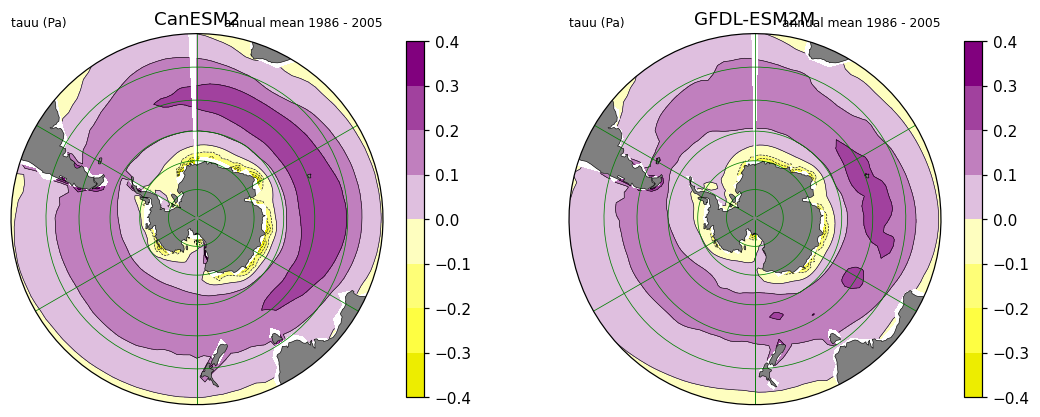

Process Dask Worker process (from Nanny):
Traceback (most recent call last):
Process Dask Worker process (from Nanny):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/base_events.py", line 691, in run_until_complete
    return future.result()
           ^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/nanny.py", line 985, in run
    await worker.finished()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/core.py", line 494, in finished
    await self._event_finished.wait()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/locks.py", line 212, in wait
    await fut
asyncio.except

In [7]:
# Contour levels and colours of the original diagnostic
levels = np.arange(-0.4, 0.4 + 0.1 / 2, 0.1)
cmap = ListedColormap(np.array([
    [237.6, 237.6, 0.], [255, 255, 66.4], [255, 255, 119.6],
    [255, 255, 191.8], [223.8, 191.8, 223.8],
    [192.8, 127.5, 190.8], [161.6, 65.3, 158.6],
    [129.5, 1.0, 126.5]]) / 256.0)
norm = BoundaryNorm(levels, ncolors=cmap.N, extend="neither")

# circular boundary for the polar stereographic axes
theta = np.linspace(0, 2 * np.pi, 100)
circle = mpath.Path(
    np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + [0.5, 0.5])

cubes = tauu_cubes
fig = plt.figure(figsize=(6 * len(cubes), 6))

for iplot, (name, cube) in enumerate(cubes.items()):
    data = np.ma.masked_invalid(cube.data) * 1.0
    lat = coord_1d_or_2d(cube, "latitude")
    lon = coord_1d_or_2d(cube, "longitude")
    if lat.ndim == 1:
        lon2d, lat2d = np.meshgrid(lon, lat)
    else:
        lat2d, lon2d = lat, lon

    ax = fig.add_subplot(1, len(cubes), iplot + 1,
                         projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, -30.0], ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)

    filled = ax.contourf(lon2d, lat2d, data, levels=levels, cmap=cmap,
                         norm=norm, extend="neither",
                         transform=ccrs.PlateCarree())
    ax.contour(lon2d, lat2d, data, levels=levels, colors="black",
               linewidths=0.4, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="grey", zorder=2)
    ax.coastlines(linewidth=0.4, zorder=3)
    ax.gridlines(color="green", linewidth=0.5)
    ax.set_title(name)
    ax.text(0.0, 1.02, "tauu (Pa)", transform=ax.transAxes, fontsize=8)
    ax.text(1.0, 1.02, "annual mean 1986 - 2005", ha="right",
            transform=ax.transAxes, fontsize=8)
    fig.colorbar(filled, ax=ax, orientation="vertical", shrink=0.7)

plt.show()

**Figure 1: Annual-mean zonal wind stress:** Annual-mean zonal wind stress (Pa) over the Southern Ocean.